<a href="https://colab.research.google.com/github/joshuajhchoi/ai2learn/blob/master/yolov1_tf_%EC%88%98%EC%A0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from glob import glob
from PIL import Image
import matplotlib.image as mpimg
import sys
import shutil
import os

In [ ]:
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras import Model, Sequential

**YOLO MODEL**

In [ ]:
class ConvBlock(tf.keras.layers.Layer):#x, num_filters, f = 3):

    def __init__(self, num_fiters = 1024, f = 3, s = 1, p ='same',trainable = True):
        super(ConvBlock, self).__init__(trainable=trainable)

        self.conv = tfl.Conv2D(num_fiters, kernel_size=f, strides=s, padding=p, kernel_initializer = tf.keras.initializers.he_normal())
        self.bn = tfl.BatchNormalization()
        self.relu = tfl.LeakyReLU(0.1)

    def call(self, inputs, *args, **kwargs):

        with tf.device('/GPU:0'):
            x = self.conv(inputs)
            x = self.bn(x)
            x = self.relu(x)

        return x

In [ ]:
class RepBlock(tfl.Layer):

    def __init__(self, n_f1 = 256, f1 = 1, s1 = 1, p1 = 'same', n_f2 = 512, f2 = 3, s2 = 1, p2 = 'same', repeat = 4, trainable = True):
        super(RepBlock, self).__init__(trainable=trainable)

        self.conv1 = tfl.Conv2D(filters=n_f1, kernel_size=f1, strides = s1, padding = p1, kernel_initializer = tf.keras.initializers.he_normal())
        self.conv2 = tfl.Conv2D(filters=n_f2, kernel_size=f2, strides = s2, padding = p2, kernel_initializer = tf.keras.initializers.he_normal())
        self.bn1 = tfl.BatchNormalization()
        self.bn2 = tfl.BatchNormalization()
        self.relu = tfl.LeakyReLU(0.1)
        self.repeat = repeat


    def call(self, x):

        with tf.device('/GPU:0'):
            for i in range(self.repeat):
                x = self.conv1(x)
                x = self.bn1(x)
                x = self.relu(x)
                x = self.conv2(x)
                x = self.bn2(x)
                x = self.relu(x)

        return x


In [ ]:
class Yolov1(tf.keras.Model):

    def __init__(self, S=7, B=2, C=20, *args, **kwargs):
        super(Yolov1, self).__init__(*args, **kwargs)

        self.cb1 = ConvBlock(num_fiters=64, f=7,s=2, p='same')
        self.p = tfl.MaxPool2D(pool_size=2, strides=2)
        self.cb2 = ConvBlock(num_fiters=192, f=3, p='same')
        self.cb3 = ConvBlock(num_fiters=128, f=1, p='same')
        self.cb4 = ConvBlock(num_fiters=256, f=3, p='same')
        self.cb5 = ConvBlock(num_fiters=256, f=1, p='same')
        self.cb6 = ConvBlock(num_fiters=512, f=3, p='same')
        self.rp1 = RepBlock()
        self.cb7 = ConvBlock(num_fiters=512, f=1, p='same')
        self.cb8 = ConvBlock(num_fiters=1024, f=3, p='same')
        self.rp2 = RepBlock(n_f1=512, n_f2=1024, f1 = 1, f2 = 3, repeat=2)
        self.cb9 = ConvBlock(num_fiters=1024, f=3, p='same')
        self.cb3 = ConvBlock(num_fiters=1024, f=3, s=2,p = 'valid')
        self.cb10 = ConvBlock(num_fiters=1024, f=3, p='same')
        self.cb11 = ConvBlock(num_fiters=1024, f=3, p='same')
        self.flat = tfl.Flatten()
        self.lin1 = tfl.Dense(496, kernel_initializer = tf.keras.initializers.he_normal())
        self.relu = tfl.LeakyReLU(0.1)
        self.lin2 = tfl.Dense(S*S*(B*5 + C), kernel_initializer = tf.keras.initializers.he_normal())

    def call(self, inputs):#, training, mask):

        x = self.cb1(inputs)
        x = self.p(x)
        x = self.cb2(x)
        x = self.p(x)
        x = self.cb3(x)
        x = self.cb4(x)
        x = self.cb5(x)
        x = self.cb6(x)
        x = self.p(x)
        x = self.rp1(x)
        x = self.cb7(x)
        x = self.cb8(x)
        x = self.p(x)
        x = self.rp2(x)
        x = self.cb9(x)
        x = self.cb10(x)
        x = self.cb11(x)
        x = self.cb11(x)
        x = self.flat(x)
        x = self.relu(self.lin1(x))
        x = self.lin2(x)

        return x#super().call(inputs, training=training, mask=mask)

**DATASET FOR YOLO**

In [ ]:
class Dataset():#tf.data.Dataset):

    def __init__(self, img_path, label_path, annotations, S=7, B=2, C=20, transformations = None, batch_size = 8):

        self.img_path = img_path
        self.label_path = label_path
        self.annotations = pd.read_csv(annotations)
        self.transformations = transformations
        self.S = S
        self.B = B
        self.C = C
        self.batch_size = batch_size


    def images_map(self, img):

        #print(y)
        img = tf.io.read_file(self.img_path+'/'+img)
        img = tf.image.decode_jpeg(img, channels = 3)
        #print(img.shape)
        img = tf.image.resize(img, [448,448])/255.
        #print(y.numpy())

        return img


    def labels_map(self, y):

        label = tf.Variable(tf.zeros((self.S, self.S, self.C + self.B*5)), dtype = tf.float32)#,use_resource=False)
        boxes = []
        #f = tf.io.read_file(self.label_path+y)
        with open(self.label_path+'/'+y.numpy().decode('UTF-8'),'r') as f:
            for b in f:
                cls, x, y, w, h = [float(x) for x in b.replace('\n', '').split()]
                boxes.append([cls, x, y, w, h])

                #assigning center to appropriate grid
                i, j = int(self.S * y), int(self.S * x)

                xg, yg = (self.S * x) - j, (self.S * y) - i
                wg, hg = self.S*w, self.S*h

                cls = int(cls)

                if label[i,j,20] == 0:


                    label[i,j,20].assign(1)

                    label[i, j, cls].assign(1)

                    label[i, j, 21:25].assign(tf.Variable([xg, yg, wg, hg]))

        return label

    def get_one(self, index):

        img_path = self.annotations.iloc[index,0]
        label_path = self.annotations.iloc[index,1]#.values

        image = tf.Variable([img_path])#, shape = (448,448,3))
        label = tf.Variable([label_path])#, shape = (448,448,3))
        #print(data.shape)
        image = tf.map_fn(self.images_map, image, fn_output_signature = tf.float32)
        label = tf.map_fn(self.labels_map, label, fn_output_signature = tf.float32)

        data = tf.data.Dataset.from_tensor_slices((image, label))

        return data

    def get_batch(self):

        batch_size = self.batch_size
        batch_start = 0
        n_batch = len(self.annotations)//batch_size

        for i in range(n_batch):

            img_path = self.annotations.iloc[batch_start:batch_start+batch_size,0]
            label_path = self.annotations.iloc[batch_start:batch_start+batch_size,1]#.values

            image = tf.Variable(img_path)#, shape = (448,448,3))
            label = tf.Variable(label_path)

            image = tf.map_fn(self.images_map, image, fn_output_signature = tf.float32)
            label = tf.map_fn(self.labels_map, label, fn_output_signature = tf.float32)

            image_ds = tf.data.Dataset.from_tensor_slices(image).batch(batch_size)
            label_ds = tf.data.Dataset.from_tensor_slices(label).batch(batch_size)

            #data = tf.data.Dataset.zip((image_ds, label_ds)).batch(batch_size)

            batch_start += 8

            yield image_ds, label_ds

In [ ]:
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar -O VOCtrainval.tar

--2022-09-30 00:57:21--  http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.152
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.152|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1999639040 (1.9G) [application/x-tar]
Saving to: ‘VOCtrainval.tar’

VOCtrainval.tar     100%[===================>]   1.86G  28.2MB/s    in 69s     

2022-09-30 00:58:31 (27.6 MB/s) - ‘VOCtrainval.tar’ saved [1999639040/1999639040]



In [ ]:
!tar -xvf VOCtrainval.tar

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
VOCdevkit/VOC2012/SegmentationClass/2008_001874.png
VOCdevkit/VOC2012/SegmentationClass/2008_001876.png
VOCdevkit/VOC2012/SegmentationClass/2008_001882.png
VOCdevkit/VOC2012/SegmentationClass/2008_001885.png
VOCdevkit/VOC2012/SegmentationClass/2008_001895.png
VOCdevkit/VOC2012/SegmentationClass/2008_001896.png
VOCdevkit/VOC2012/SegmentationClass/2008_001926.png
VOCdevkit/VOC2012/SegmentationClass/2008_001966.png
VOCdevkit/VOC2012/SegmentationClass/2008_001971.png
VOCdevkit/VOC2012/SegmentationClass/2008_001992.png
VOCdevkit/VOC2012/SegmentationClass/2008_001997.png
VOCdevkit/VOC2012/SegmentationClass/2008_002032.png
VOCdevkit/VOC2012/SegmentationClass/2008_002043.png
VOCdevkit/VOC2012/SegmentationClass/2008_002064.png
VOCdevkit/VOC2012/SegmentationClass/2008_002066.png
VOCdevkit/VOC2012/SegmentationClass/2008_002067.png
VOCdevkit/VOC2012/SegmentationClass/2008_002073.png
VOCdevkit/VOC2012/SegmentationClass/2008_002079.png
VOCdevkit/VOC2012/Segmentati

## Reading Images

In [ ]:
img_w, img_h = 512, 512
batch_size = 4
num_classes = 21
def read_img(image_path,mask=False):
    img = tf.io.read_file(image_path)
    if mask:
      img = tf.image.decode_png(img, channels=1)
      # npimg = img.numpy()
      print(type(img))
      # img = tf.where(img == 255,  0, 0)#tf.cast(img, tf.int32))
      img.set_shape([None, None, 1])
      img = (tf.image.resize(images=img, size=[
                    img_h, img_w]))
      img = tf.cast(img,tf.float32)
      print(img.get_shape)
    else:
      img = tf.image.decode_png(img, channels=3)
      img.set_shape([None, None, 3])
      img = (tf.image.resize(images=img, size=[
                    img_h, img_w]))
      img = tf.cast(img,tf.float32) / 127.5 - 1
    return img

def load_data(img_list,mask_list):
  img = read_img(img_list)
  mask = read_img(mask_list,mask=True)
  return img, mask

In [ ]:
def data_generator(img_list,mask_list):
  dataset = tf.data.Dataset.from_tensor_slices((img_list,
                                                    mask_list))
  dataset = dataset.map(load_data,num_parallel_calls=
                        tf.data.experimental.AUTOTUNE)
  dataset = dataset.batch(batch_size,drop_remainder=True)
  dataset = dataset.repeat()
  dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
  return dataset
path = '/content/VOCdevkit/VOC2012/trainImages'
maskList = sorted(glob('VOCdevkit/VOC2012/SegmentationClass/*'))
dst = '/content/VOCdevkit/VOC2012/trainImages/'
isExist = os.path.exists(path)

if not isExist:
  # Create a new directory because it does not exist
  print("making new directory")
  os.mkdir(path)

for image in maskList:
  src = "VOCdevkit/VOC2012/JPEGImages/" + image[36:-3] + "jpg"
  print("processing = ", image)
  img = np.array(Image.open(image))


  img= np.where(img == 255, 0, img)

  img = Image.fromarray(img)
  img.save(image)
  shutil.copy(src,dst)
print("PreProcessing done")
train_images_folder = sorted(glob('VOCdevkit/VOC2012/trainImages/*'))[:2800]
train_mask_folder = sorted(glob('VOCdevkit/VOC2012/SegmentationClass/*'))[:2800]
valid_images_folder = sorted(glob('VOCdevkit/VOC2012/trainImages/*'))[2801:2913]
valid_mask_folder = sorted(glob('VOCdevkit/VOC2012/SegmentationClass/*'))[2801:2913]

train_dataset = data_generator(train_images_folder,train_mask_folder)
valid_dataset = data_generator(valid_images_folder,valid_mask_folder)

processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000032.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000033.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000039.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000042.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000061.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000063.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000068.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000121.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000123.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000129.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000170.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000175.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000187.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000241.png
processing =  VOCdevkit/VOC2012/SegmentationClass/2007_000243.png
processing

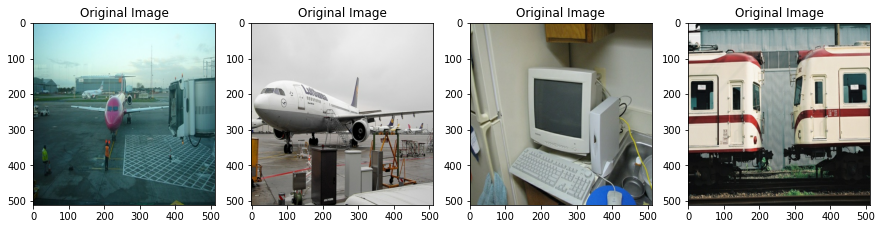

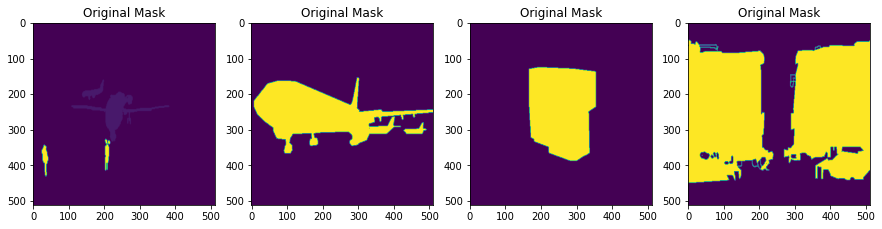

In [ ]:
dataset = train_dataset
plt.figure(figsize=(15,15))
for i in range(batch_size):
  for val in dataset.take(1):
    img = tf.cast((val[0][i]+1)*127.5,tf.uint8)
    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title("Original Image")
plt.show()

plt.figure(figsize=(15,15))
for i in range(batch_size):
  for val in dataset.take(1):
    plt.subplot(1,4,i+1)
    plt.imshow(tf.squeeze(val[1][i]))
    plt.title("Original Mask")
plt.show()

In [ ]:
# with tf.device('/GPU:0'):
#    dataset = Dataset('../input/pascalvoc-yolo/images', '../input/pascalvoc-yolo/labels', '../input/pascalvoc-yolo/train.csv',batch_size = 8)#

In [ ]:
tf.__version__

'2.4.1'

**UTILS**

In [ ]:
def iOU(pred, target, mode = 'midpoint'):

    if mode == 'midpoint':

        p_x1 = pred[0:1] - pred[2:3]/2
        p_x2 = pred[0:1] + pred[2:3]/2
        p_y1 = pred[1:2] - pred[3:4]/2
        p_y2 = pred[1:2] + pred[3:4]/2

        t_x1 = target[0:1] - target[2:3]/2
        t_x2 = target[0:1] + target[2:3]/2
        t_y1 = target[1:2] - target[3:4]/2
        t_y2 = target[1:2] + target[3:4]/2

    i_x1 = max(p_x1, t_x1)
    i_x2 = min(p_x2, t_x2)
    i_y1 = max(p_y1, t_y1)
    i_y2 = min(p_y2, t_y2)

    inter = (i_x2 - i_x1)*(i_y2 - i_y1)

    union = (p_x2 - p_x1)*(p_y2 - p_y1) + (t_x2 - t_X1)*(t_y2 - t_y1)

    iou = inter/(union - inter)

    return iou

**BOSS FIGHT !!(LOSS FUNCTION)**

In [ ]:
class YoloLoss(tf.keras.losses.Loss):

    def __init__(self, S = 7, B = 2, C = 20):
        super(YoloLoss, self).__init__()

        self.S = S
        self.B = B
        self.C = C
        self.mse = tf.keras.losses.MeanSquaredError()


    def call(self, y_true, y_pred):

        y_pred = y_pred.reshape((-1, self.S, self.S, (self.C + self.B * 5)))

        iou1 = iOU(y_pred[...,21:25], y_true[...,21:25])
        iou2 = iOU(y_pred[...,26:30], y_true[...,21:25])

        ious = tf.stack([tf.expand_dims(iou1, axis = 0), tf.expand_dims(iou2, axis = 0)], axis = 0)

        best_boxes = tf.argmax(ious, axis= -1)

        exist_box = tf.argmax(y_true[...,20:21])


        #box coordinates
        pred_box = exist_box * (
            (best_boxes) * y_pred[...,26:30] + (1 - best_boxes) * y_pred[...,21:25]
        )

        true_box = y_true[...,21:25]

        pred_box[...,2:4] = tf.sign(pred_box[...,2:4]) * tf.sqrt(tf.abs(pred_box[...,2:4]))

        true_box[...,2:4] = tf.sqrt(true_box[...,2:4])

        box_loss = self.mse(pred_box, true_box)

